# RQ2 – Fairness Assessment

Uses available group columns in the provided cybersecurity dataset because no gender/age protected attributes are present.

In [1]:
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

OUTPUT_DIR = "responsible_ai_outputs"
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables_csv")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures_pdf")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

def find_file(possible_names):
    """Find uploaded dataset in current folder, /mnt/data, or Kaggle input folders."""
    search_roots = [".", "/mnt/data", "/kaggle/input"]
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for name in possible_names:
            matches = glob.glob(os.path.join(root, "**", name), recursive=True)
            if matches:
                return matches[0]

    all_csvs = []
    for root in search_roots:
        if os.path.exists(root):
            all_csvs += glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
    for f in all_csvs:
        base = os.path.basename(f).lower()
        for name in possible_names:
            token = name.replace("(1)", "").replace(".csv","").lower()
            if token in base:
                return f
    raise FileNotFoundError(f"Could not find any of: {possible_names}")

CYBER_FILE = find_file([
    "cybersecurity_intrusion_data(1).csv",
    "cybersecurity_intrusion_data.csv"
])
cyber = pd.read_csv(CYBER_FILE)

target_col = "attack_detected"
drop_cols = ["session_id"]
cyber = cyber.drop(columns=[c for c in drop_cols if c in cyber.columns])

X = cyber.drop(columns=[target_col])
y = cyber[target_col].astype(int)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)

model = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, zero_division=0),
    "recall": recall_score(y_test, pred, zero_division=0),
    "f1": f1_score(y_test, pred, zero_division=0),
}
print("Loaded:", CYBER_FILE)
print("Dataset shape:", cyber.shape)
print("Metrics:", metrics)

def save_bar(df, x, y, title, xlabel, ylabel, filename, rotation=30):
    plt.figure(figsize=(8, 4.8))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)

Loaded: ./cybersecurity_intrusion_data.csv
Dataset shape: (9537, 10)
Metrics: {'accuracy': 0.8846960167714885, 'precision': 1.0, 'recall': 0.7420262664165104, 'f1': 0.8519116855142703}


Saved table: responsible_ai_outputs/tables_csv/RQ2_fairness_by_operational_groups.csv


,Group_Attribute,Group,Records,Actual_Attack_Rate,Predicted_Attack_Rate,Fairness_Score
9,browser_type,Unknown,116,0.7672,0.7328,0.9655
8,browser_type,Safari,148,0.3919,0.2905,0.8986
6,browser_type,Edge,357,0.4650,0.3585,0.8936
5,browser_type,Chrome,1277,0.4221,0.3062,0.8841
7,browser_type,Firefox,487,0.4394,0.2957,0.8563
4,encryption_used,DES,704,0.4474,0.3423,0.8949
3,encryption_used,AES,1209,0.4367,0.3251,0.8883
0,protocol_type,ICMP,107,0.3645,0.2897,0.9252
2,protocol_type,UDP,594,0.4512,0.3367,0.8855
1,protocol_type,TCP,1684,0.4507,0.3325,0.8818


,Group_Attribute,Fairness_Score
0,browser_type,0.8996
1,encryption_used,0.8916
2,protocol_type,0.8975
3,unusual_time_access,0.8785


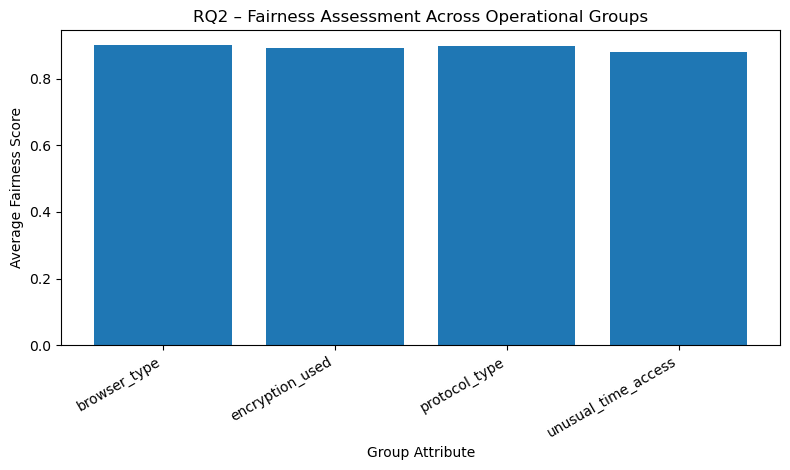

Saved figure: responsible_ai_outputs/figures_pdf/RQ2_fairness_summary.pdf


In [2]:
test_df = X_test.copy()
test_df["actual_attack"] = y_test.values
test_df["predicted_attack"] = pred
test_df["risk_probability"] = proba

group_cols = [c for c in ["protocol_type", "encryption_used", "browser_type", "unusual_time_access"] if c in test_df.columns]

rows = []
for col in group_cols:
    for group_value, g in test_df.groupby(col):
        if len(g) < 20:
            continue
        selection_rate = g["predicted_attack"].mean()
        actual_rate = g["actual_attack"].mean()
        # fairness score close to 1 means predicted attack rate is close to actual attack rate for the group
        fairness_score = 1 - abs(selection_rate - actual_rate)
        rows.append({
            "Group_Attribute": col,
            "Group": str(group_value),
            "Records": len(g),
            "Actual_Attack_Rate": round(actual_rate, 4),
            "Predicted_Attack_Rate": round(selection_rate, 4),
            "Fairness_Score": round(float(fairness_score), 4)
        })

fairness_df = pd.DataFrame(rows).sort_values(["Group_Attribute", "Fairness_Score"], ascending=[True, False])
csv_path = os.path.join(TABLE_DIR, "RQ2_fairness_by_operational_groups.csv")
fairness_df.to_csv(csv_path, index=False)
print("Saved table:", csv_path)
display(fairness_df)

summary = fairness_df.groupby("Group_Attribute", as_index=False)["Fairness_Score"].mean()
summary["Fairness_Score"] = summary["Fairness_Score"].round(4)
summary_path = os.path.join(TABLE_DIR, "RQ2_fairness_summary.csv")
summary.to_csv(summary_path, index=False)
display(summary)

save_bar(
    summary,
    x="Group_Attribute",
    y="Fairness_Score",
    title="RQ2 – Fairness Assessment Across Operational Groups",
    xlabel="Group Attribute",
    ylabel="Average Fairness Score",
    filename="RQ2_fairness_summary.pdf"
)